In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import jax
import jax.numpy as jnp 
import jax.random as jr
import lineax as lx
import diffrax as dx
from scipy.integrate import odeint
import matplotlib.pyplot as plt

$$ \frac{\partial ^2 \theta}{\partial t^2} + \frac{g}{l} sin \theta = 0$$


Key points to improve 

- Using sin instead of tanh 
- Using a larger neural network if the problem is high
- Using Softplus / GELU / Swish as a activation function

In [2]:
def sol_sde_pend(k, m, t_0, sigm, t0, t1, key):
    
    w_sq = k / m
    
    def drift(t,y,args):
        theta, omega = y
        return jnp.stack([omega, -w_sq * jnp.sin(theta)])

    def diff(t, y, args):
        diagonal = jnp.stack([0.0, sigm])
        return lx.DiagonalLinearOperator(diagonal)
        
    brow_m = dx.VirtualBrownianTree(t0, t1, tol=1e-3, shape=(2,), key=key)
    terms = dx.MultiTerm(dx.ODETerm(drift), dx.ControlTerm(diff, brow_m))
    
    solver = dx.Euler()
    
    y0 = jnp.array([t_0, 0.0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0,t1,1000), dense=True)
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=y0, saveat=saveat)
    
    return sol 

key = jr.PRNGKey(42)
sol = sol_sde_pend(4.0, 1.0, 2.0, 0.5, 0, 20, key)

# Print solution info
#print(f"Time span: {sol.t0} to {sol.t1}")
#print(f"Number of saved points: {len(sol.ts)}")
#print(f"Solution shape: {sol.ys.shape}")
#print(f"First state (theta, omega): {sol.ys[:, 0]}")
#print(f"Last state (theta, omega): {sol.ys[:, -1]}")

In [11]:
class Net(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        
    def forward(self, x):
        x = torch.sin(self.fc1(x))
        x = torch.cos(self.fc2(x))
        x = torch.sin(self.fc3(x))
        x = self.fc4(x)
        
        return x
    

In [12]:
def physics_loss(model, t_collocation, g=9.81, l=1.0):
    t_collocation.requires_grad_(True)

    theta = model(t_collocation)
    
    d_theta = torch.autograd.grad( #first derivate d0/dt
        theta, t_collocation,
        grad_outputs=torch.ones_like(theta),
        create_graph=True,
        retain_graph=True
    )[0]
    
    d2_theta = torch.autograd.grad(  # d**0/dt^2
        d_theta, t_collocation,
        grad_outputs=torch.ones_like(d_theta),
        create_graph=True,
        retain_graph=True
    )[0]
    # calculating the residual equals the equation in top of the notebook
    #residual = d2_theta + ( g / l ) * torch.sin(theta)

    residual = d2_theta  + torch.Tensor( (g/l) * torch.sin(theta))
    
    loss_ode = torch.mean(residual ** 2) # MSE of the equation aim to be 0
    
    return loss_ode

def initial_cond_loss(model, t0, theta_0, omega_0):
    t0.requires_grad_(True)
    
    theta_pred = model(t0)
    
    d_theta_pred = torch.autograd.grad(
        theta_pred, t0,
        grad_outputs=torch.ones_like(theta_pred),
        create_graph=True,
        retain_graph=True
    )[0]
    
    loss_ic = torch.mean( (theta_pred - theta_0) ** 2) + torch.mean( (d_theta_pred - omega_0) ** 2)
    
    return loss_ic

In [13]:
def output_data(g=9.81, l=1.0, theta0=0.5, omega0=0.0, t_max=10, steps=1000):
    
    def system(y,t,g,l):
        theta, omega = y 
        dydt = [omega, -(g/l) * jnp.sin(theta)]
        return dydt
    
    t = jnp.linspace(0, t_max, steps)
    sol = odeint(system, [theta0, omega0], t, args=(g,l))
    
    return torch.tensor(t, dtype=torch.float32).view(-1,1), \
        torch.tensor(sol[:, 0], dtype=torch.float32).view(-1,1)

def out_with_resistence(g, l, theta0, omega0, b, t_max, steps):
    
    def system(y,t,g,l,b):
        theta, omega = y
        dydt = [omega, -(g/l) * jnp.sin(theta) - b * omega]
        return dydt    
    
    t = jnp.linspace(0, t_max, steps)
    
    sol = odeint(system, [theta0, omega0], t,g,l,b)
    
    return torch.tensor(t, dtype=torch.float32).view(-1.1), \
        torch.tensor(sol[:, 0], dtype=torch.float32).view(-1,1)


def generate_data():
    t, theta = output_data(g=9.81, l=1.0, t_max=100, steps=1_000)
    return t, theta

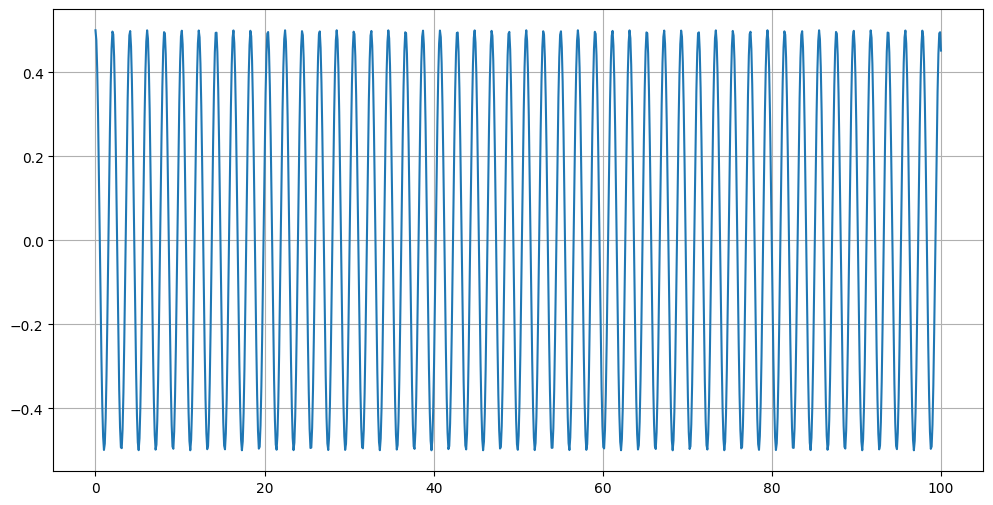

torch.Size([1000, 1]) torch.Size([1000, 1])


In [14]:
x_data , y_data = generate_data()

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(x_data, y_data)
ax.grid(True)
plt.show()

print(x_data.shape, y_data.shape)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train(x_collocation, seed=42, epochs=5000, lr=1e-3):
    torch.manual_seed(seed)
    
    model = Net().to(device)
    optm = torch.optim.Adam(model.parameters(),lr=lr)
    
    t0 = torch.tensor([[0.0]], requires_grad=True, device=device)
    theta_0 = torch.tensor([[0.5]], device=device)
    omega_0 =  torch.tensor([[0.0]], device=device)
    
    t_collocation = x_collocation.clone().to(device).requires_grad_(True)
       
    for i in range(epochs):
        optm.zero_grad()
        loss_ode = physics_loss(model, t_collocation, g=9.81, l=1.0)
        
        loss_ic = initial_cond_loss(model, t0, theta_0, omega_0)
        
        loss = loss_ode + (10.0 * loss_ic)
        
        loss.backward()
        optm.step()
        
        if i % 100 == 0:
            print(f"epoch: {i}, loss: {loss.item():>7f}")
            
    return model

Using device: cuda


epoch: 0, loss: 3.475729
epoch: 100, loss: 2.586778
epoch: 200, loss: 2.324793
epoch: 300, loss: 2.173450
epoch: 400, loss: 2.035674
epoch: 500, loss: 1.897798
epoch: 600, loss: 1.755998
epoch: 700, loss: 1.609194
epoch: 800, loss: 1.457790
epoch: 900, loss: 1.303351
epoch: 1000, loss: 1.148414
epoch: 1100, loss: 0.996277
epoch: 1200, loss: 0.850718
epoch: 1300, loss: 0.715602
epoch: 1400, loss: 0.594403
epoch: 1500, loss: 0.489747
epoch: 1600, loss: 0.403067
epoch: 1700, loss: 0.334432
epoch: 1800, loss: 0.282576
epoch: 1900, loss: 0.245169
epoch: 2000, loss: 0.219288
epoch: 2100, loss: 0.201949
epoch: 2200, loss: 0.190537
epoch: 2300, loss: 0.183010
epoch: 2400, loss: 0.177922
epoch: 2500, loss: 0.174318
epoch: 2600, loss: 0.171606
epoch: 2700, loss: 0.169432
epoch: 2800, loss: 0.167591
epoch: 2900, loss: 0.165964
epoch: 3000, loss: 0.164480
epoch: 3100, loss: 0.163098
epoch: 3200, loss: 0.161790
epoch: 3300, loss: 0.160537
epoch: 3400, loss: 0.159325
epoch: 3500, loss: 0.158144
epoc

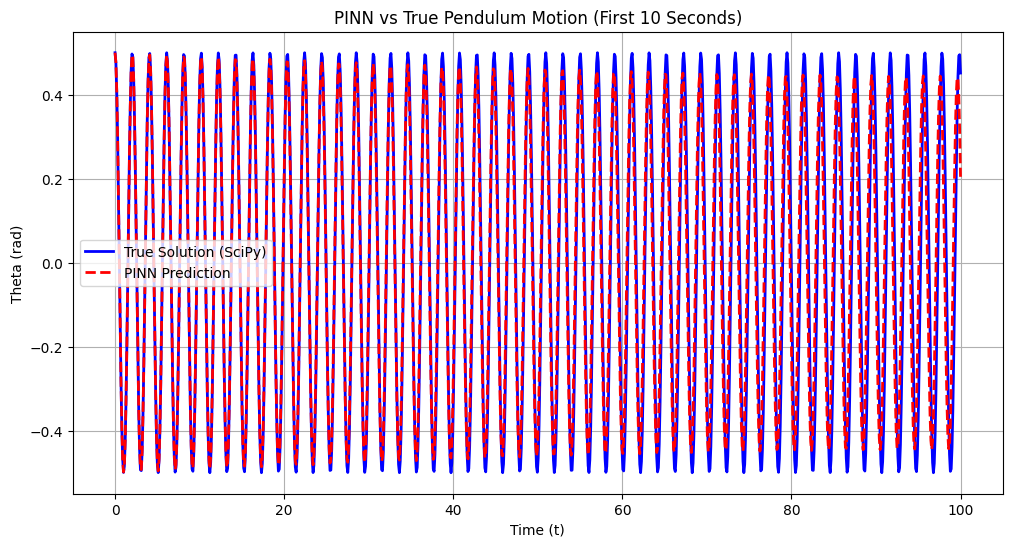

In [16]:
#time_slice = 100
#t_train = x_data[:time_slice]
t_train = x_data
# Execute the training loop
trained_model = train(t_train, epochs=300_000, lr=1e-5)

trained_model.eval()
with torch.no_grad():
    y_pred = trained_model(t_train.to(device)).detach().cpu()

# Plot True Solution vs PINN Prediction
fig, ax = plt.subplots(figsize=(12, 6))

# SciPy Ground Truth
#ax.plot(t_train.numpy(), y_data[:time_slice].numpy(), label="True Solution (SciPy)", color="blue", linewidth=2)
ax.plot(t_train.numpy(), y_data.numpy(), label="True Solution (SciPy)", color="blue", linewidth=2)

# PINN Output
ax.plot(t_train.numpy(), y_pred.numpy(), label="PINN Prediction", color="red", linestyle="--", linewidth=2)

ax.set_xlabel("Time (t)")
ax.set_ylabel("Theta (rad)")
ax.set_title("PINN vs True Pendulum Motion (First 10 Seconds)")
ax.legend()
ax.grid(True)

plt.show()

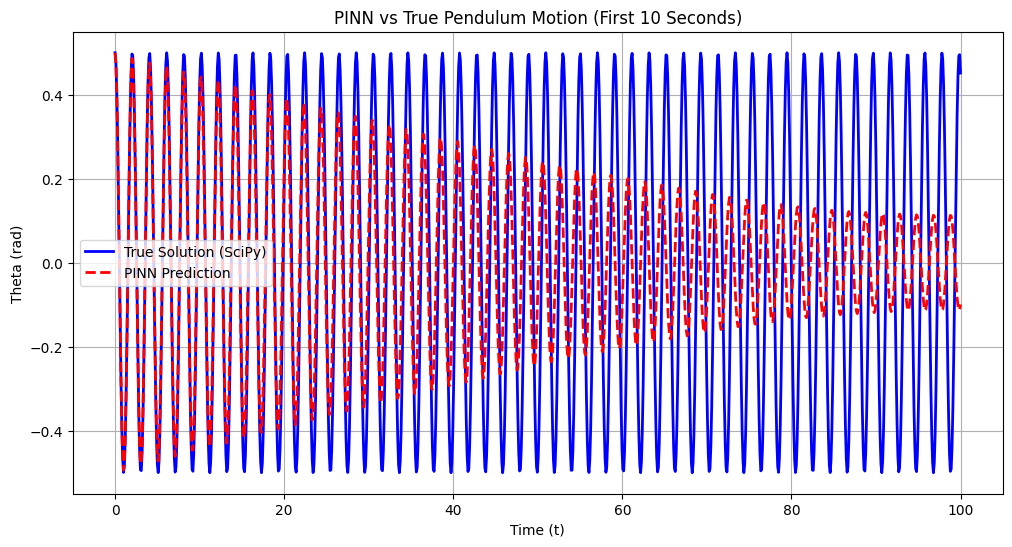

In [10]:
trained_model.eval()
with torch.no_grad():
    y_pred = trained_model(t_train.to(device)).detach().cpu()

# Plot True Solution vs PINN Prediction
fig, ax = plt.subplots(figsize=(12, 6))

# SciPy Ground Truth
#ax.plot(t_train.numpy(), y_data[:time_slice].numpy(), label="True Solution (SciPy)", color="blue", linewidth=2)
ax.plot(t_train.numpy(), y_data.numpy(), label="True Solution (SciPy)", color="blue", linewidth=2)

# PINN Output
ax.plot(t_train.numpy(), y_pred.numpy(), label="PINN Prediction", color="red", linestyle="--", linewidth=2)

ax.set_xlabel("Time (t)")
ax.set_ylabel("Theta (rad)")
ax.set_title("PINN vs True Pendulum Motion (First 10 Seconds)")
ax.legend()
ax.grid(True)

plt.show()